In [1]:
import json

json_path = "/root/workspace/LongSumm/jaehyeok/datasets/mapping_gold_summary_for_training_sets.json"

with open(json_path, "r") as f:
    data = json.load(f)

len(data)

488

In [31]:
data[key_list[0]]

{'paper_id': '39357436',
 'gold_summary': 'Word based language models suffer from the problem of rare or Out of Vocabulary (OOV) words.\nLearning representations for OOV words directly on the end task often results in poor representation.\nThe alternative is to replace all the rare words with a single, unique representation (loss of information) or use character level models to obtain word representations (they tend to miss on the semantic relationship).\nThe paper proposes to learn a network that can predict the representations of words using auxiliary data (referred to as definitions) such as dictionary definitions, Wikipedia infoboxes, the spelling of the word etc.\nThe auxiliary data encoders are trained jointly with the end task to ensure that word representations align with the requirements of the end task.\nApproach  Given a rare word w, let d(w) = <x1, x2…> denote its defination where xi are words.\nd(w) is fed to a defination reader network f (LSTM) and its last state is used 

In [40]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt

# === JSON 파일 로드 및 데이터 집계 ===
records = []
mappings = []
stats = []

key_list = list(data.keys())
data[key_list[0]]

for key in key_list:
    cnt_data = data[key]
    
    stat = cnt_data.get('stats', {})
    rouge = cnt_data.get('rouge_scores', {})
    mapping = cnt_data.get('mappings', {})

    stat['file'] = key
    stats.append(stat)
    
    for mapp in mapping:
        mapp['file'] = key
        mapp['num_summary_sentences'] = data[key]['stats'].get('num_summary_sentences', 1)
        mapp['num_paper_sentences'] = data[key]['stats'].get('num_paper_sentences', 1)
        mappings.append(mapp)

    records.append({
        'file': key,
        'avg_similarity': stat.get('avg_similarity', 0.0),
        'rouge1_f': rouge.get('rouge1', {}).get('fmeasure', 0.0),
        'rouge2_f': rouge.get('rouge2', {}).get('fmeasure', 0.0),
        'rougeL_f': rouge.get('rougeL', {}).get('fmeasure', 0.0),
    })

# === DataFrame 생성 및 표시 ===
df_records = pd.DataFrame(records)
df_mappings = pd.DataFrame(mappings)
df_stats = pd.DataFrame(stats)

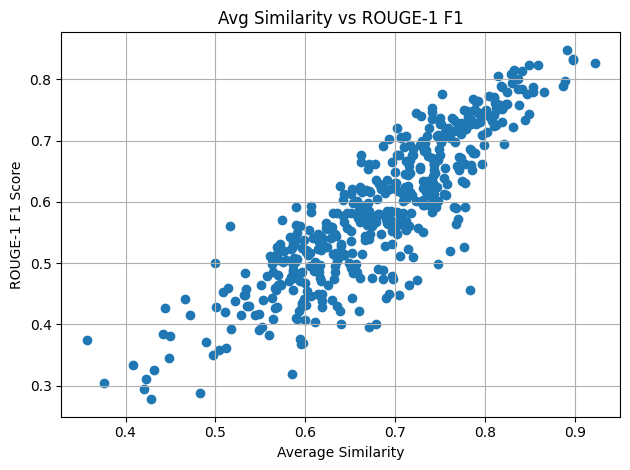

In [19]:
# === 시각화: df_records가 비어있지 않을 때만 실행 ===
plt.figure()
plt.scatter(df_records['avg_similarity'], df_records['rouge1_f'])
plt.xlabel('Average Similarity')
plt.ylabel('ROUGE-1 F1 Score')
plt.title('Avg Similarity vs ROUGE-1 F1')
plt.grid(True)
plt.tight_layout()
plt.show()


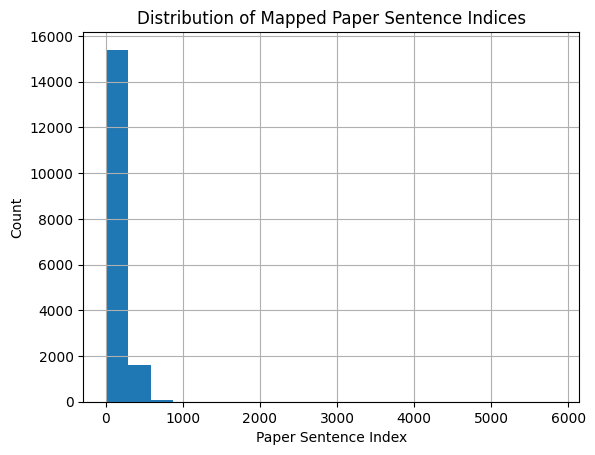

In [42]:
plt.hist(df_mappings['paper_idx'].dropna(), bins=20)
plt.xlabel('Paper Sentence Index')
plt.ylabel('Count')
plt.title('Distribution of Mapped Paper Sentence Indices')
plt.grid(True)

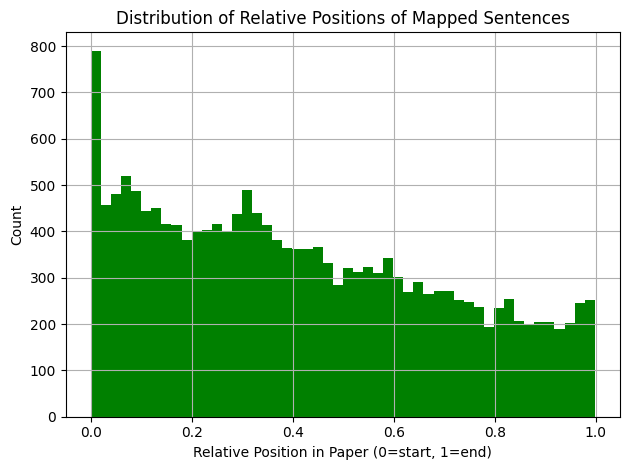

In [48]:
plt.hist(df_mappings['paper_idx']/df_mappings['num_paper_sentences'], bins=50, color='green')
plt.xlabel('Relative Position in Paper (0=start, 1=end)')
plt.ylabel('Count')
plt.title('Distribution of Relative Positions of Mapped Sentences')
plt.grid(True)

plt.tight_layout()
plt.show()

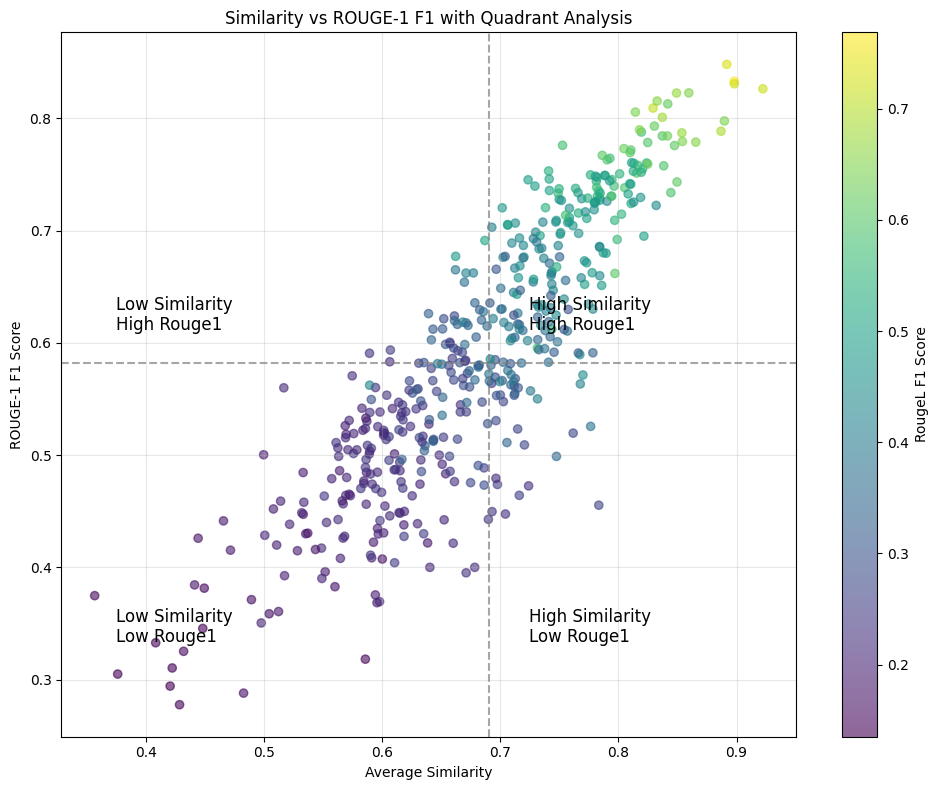

In [60]:
# Create a scatter plot with quadrants
plt.figure(figsize=(10, 8))

# Calculate median values for x and y axes to create quadrants
median_similarity = df_records['avg_similarity'].median()
median_rouge1 = df_records['rouge1_f'].median()

# Plot the scatter points
plt.scatter(df_records['avg_similarity'], df_records['rouge1_f'], 
           alpha=0.6, c=df_records['rougeL_f'], cmap='viridis')

# Add quadrant lines
plt.axvline(x=median_similarity, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=median_rouge1, color='gray', linestyle='--', alpha=0.7)

# Add labels for quadrants
plt.text(df_records['avg_similarity'].min()*1.05, median_rouge1*1.05, 
         'Low Similarity\nHigh Rouge1', fontsize=12, ha='left')
plt.text(median_similarity*1.05, median_rouge1*1.05, 
         'High Similarity\nHigh Rouge1', fontsize=12, ha='left')
plt.text(df_records['avg_similarity'].min()*1.05, df_records['rouge1_f'].min()*1.2, 
         'Low Similarity\nLow Rouge1', fontsize=12, ha='left')
plt.text(median_similarity*1.05, df_records['rouge1_f'].min()*1.2, 
         'High Similarity\nLow Rouge1', fontsize=12, ha='left')

# Add colorbar
cbar = plt.colorbar()
cbar.set_label('RougeL F1 Score')

plt.xlabel('Average Similarity')
plt.ylabel('ROUGE-1 F1 Score')
plt.title('Similarity vs ROUGE-1 F1 with Quadrant Analysis')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

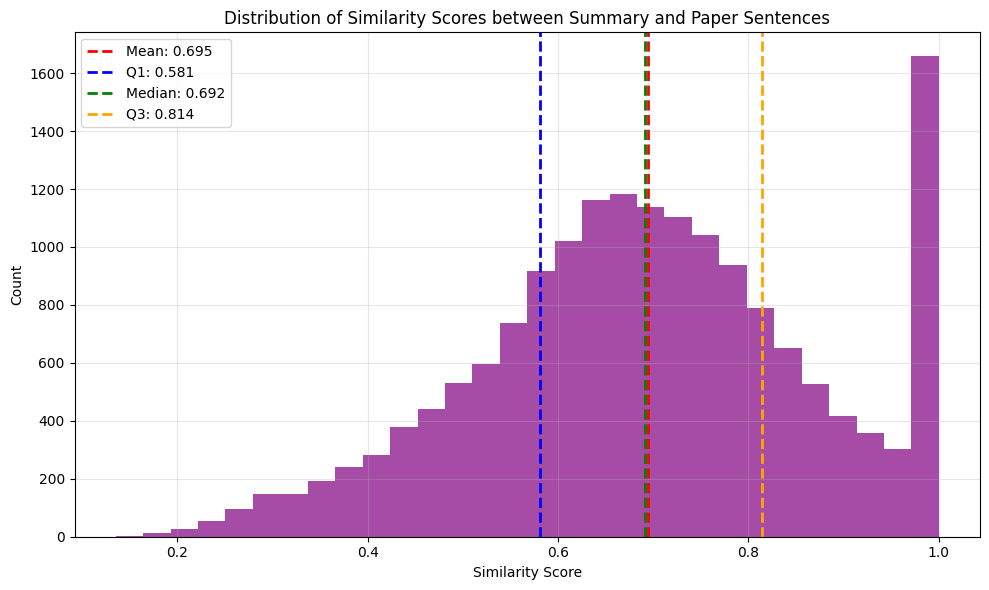

In [62]:
# Plot histogram of similarity scores from df_mappings
plt.figure(figsize=(10, 6))
plt.hist(df_mappings['similarity'], bins=30, color='purple', alpha=0.7)
plt.xlabel('Similarity Score')
plt.ylabel('Count')
plt.title('Distribution of Similarity Scores between Summary and Paper Sentences')
plt.grid(True, alpha=0.3)
plt.axvline(df_mappings['similarity'].mean(), color='red', linestyle='dashed', 
           linewidth=2, label=f'Mean: {df_mappings["similarity"].mean():.3f}')
plt.axvline(df_mappings['similarity'].quantile(0.25), color='blue', linestyle='dashed', 
           linewidth=2, label=f'Q1: {df_mappings["similarity"].quantile(0.25):.3f}')
plt.axvline(df_mappings['similarity'].quantile(0.5), color='green', linestyle='dashed',
              linewidth=2, label=f'Median: {df_mappings["similarity"].median():.3f}')
plt.axvline(df_mappings['similarity'].quantile(0.75), color='orange', linestyle='dashed',
           linewidth=2, label=f'Q3: {df_mappings["similarity"].quantile(0.75):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

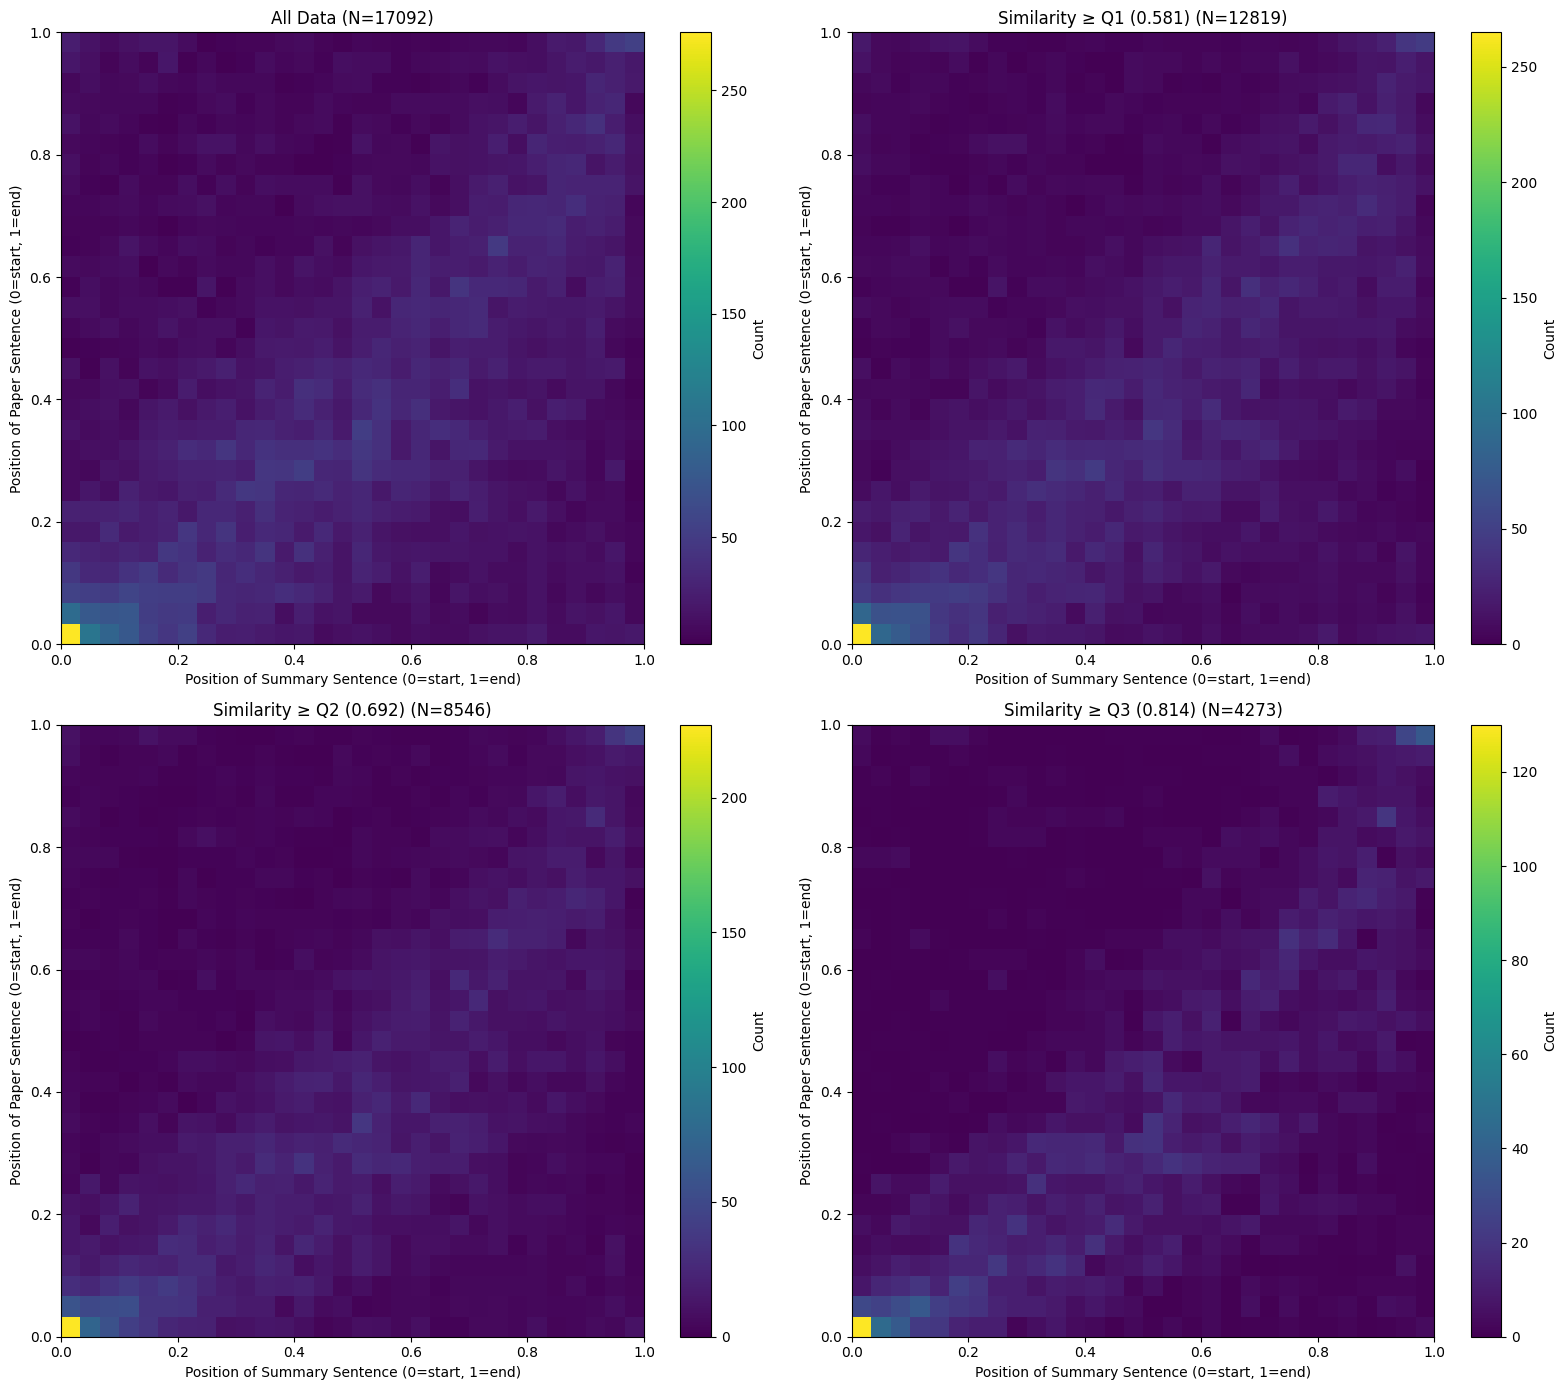

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Get quartile values for similarity
q1 = df_mappings['similarity'].quantile(0.25)
q2 = df_mappings['similarity'].median()  # Median = Q2
q3 = df_mappings['similarity'].quantile(0.75)

# Create figure with 2x2 subplots
fig = plt.figure(figsize=(16, 14))
gs = GridSpec(2, 2, figure=fig)

# Create 4 dataframes with different similarity thresholds
dfs = [
    (df_mappings, "All Data", "viridis"),
    (df_mappings[df_mappings['similarity'] >= q1], f"Similarity ≥ Q1 ({q1:.3f})", "viridis"),
    (df_mappings[df_mappings['similarity'] >= q2], f"Similarity ≥ Q2 ({q2:.3f})", "viridis"),
    (df_mappings[df_mappings['similarity'] >= q3], f"Similarity ≥ Q3 ({q3:.3f})", "viridis")
]

# Plot each heatmap
for i, (df, title, cmap) in enumerate(dfs):
    row, col = i // 2, i % 2
    ax = fig.add_subplot(gs[row, col])
    
    # Create a 2D histogram (heatmap)
    heatmap, xedges, yedges = np.histogram2d(
        df['summary_idx']/df['num_summary_sentences'], 
        df['paper_idx']/df['num_paper_sentences'],
        bins=30,
        range=[[0, 1], [0, 1]]
    )
    
    # Plot the heatmap
    im = ax.imshow(heatmap.T, 
                   origin='lower', 
                   extent=[0, 1, 0, 1],
                   aspect='auto',
                   cmap=cmap)
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Count')
    
    # Add labels and title
    ax.set_xlabel('Position of Summary Sentence (0=start, 1=end)')
    ax.set_ylabel('Position of Paper Sentence (0=start, 1=end)')
    ax.set_title(f'{title} (N={len(df)})')
    ax.grid(False)

plt.tight_layout()
plt.show()


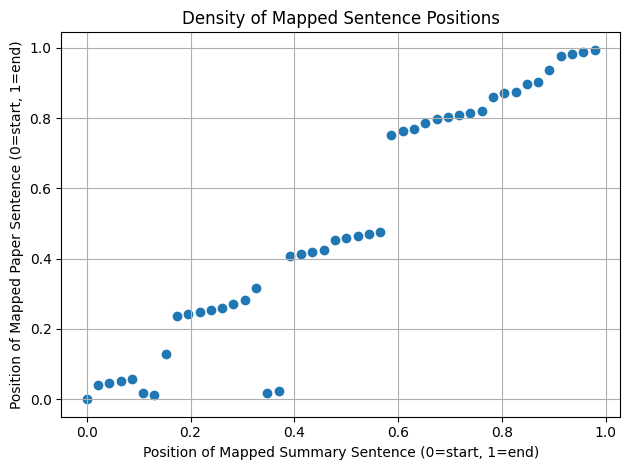

In [ ]:
spec_df = df_mappings[df_mappings['file'] == key_list[5]]

# === 시각화: df_records가 비어있지 않을 때만 실행 ===
plt.figure()
plt.scatter(spec_df['summary_idx']/spec_df['num_summary_sentences'], 
    spec_df['paper_idx']/spec_df['num_paper_sentences'])
plt.xlabel('Position of Mapped Summary Sentence (0=start, 1=end)')
plt.ylabel('Position of Mapped Paper Sentence (0=start, 1=end)')
plt.title('Density of Mapped Sentence Positions')
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
df_mappings

,summary_idx,summary_sentence,paper_idx,paper_sentence,similarity,file,num_summary_sentences,num_paper_sentences
0,0,Word based language models suffer from the pro...,218,Our method works on variable sized inputs (yie...,0.402863,39357436,16,229
1,1,Learning representations for OOV words directl...,31,2 Models\nWe review the sequence-to-sequence [...,0.454215,39357436,16,229
2,2,The alternative is to replace all the rare wor...,218,Our method works on variable sized inputs (yie...,0.338721,39357436,16,229
3,3,The paper proposes to learn a network that can...,218,Our method works on variable sized inputs (yie...,0.487886,39357436,16,229
4,4,The auxiliary data encoders are trained jointl...,54,We call the former RNN the encoder and the lat...,0.556646,39357436,16,229
...,...,...,...,...,...,...,...,...
17087,11,If the recurrent model and truncated feed-forw...,248,"Moreover, implementing the truncated approxima...",0.740161,68635574,16,429
17088,12,It can be shown that this small difference doe...,142,"Therefore, after a gradient update,\n∥∥w1recur...",0.704959,68635574,16,429
17089,13,This can be roughly interpreted as - if the gr...,46,Recurrent models are typically trained using s...,0.723244,68635574,16,429
17090,14,"The stability condition is important as, witho...",231,"In practice, unstable models can also be trunc...",0.712988,68635574,16,429
